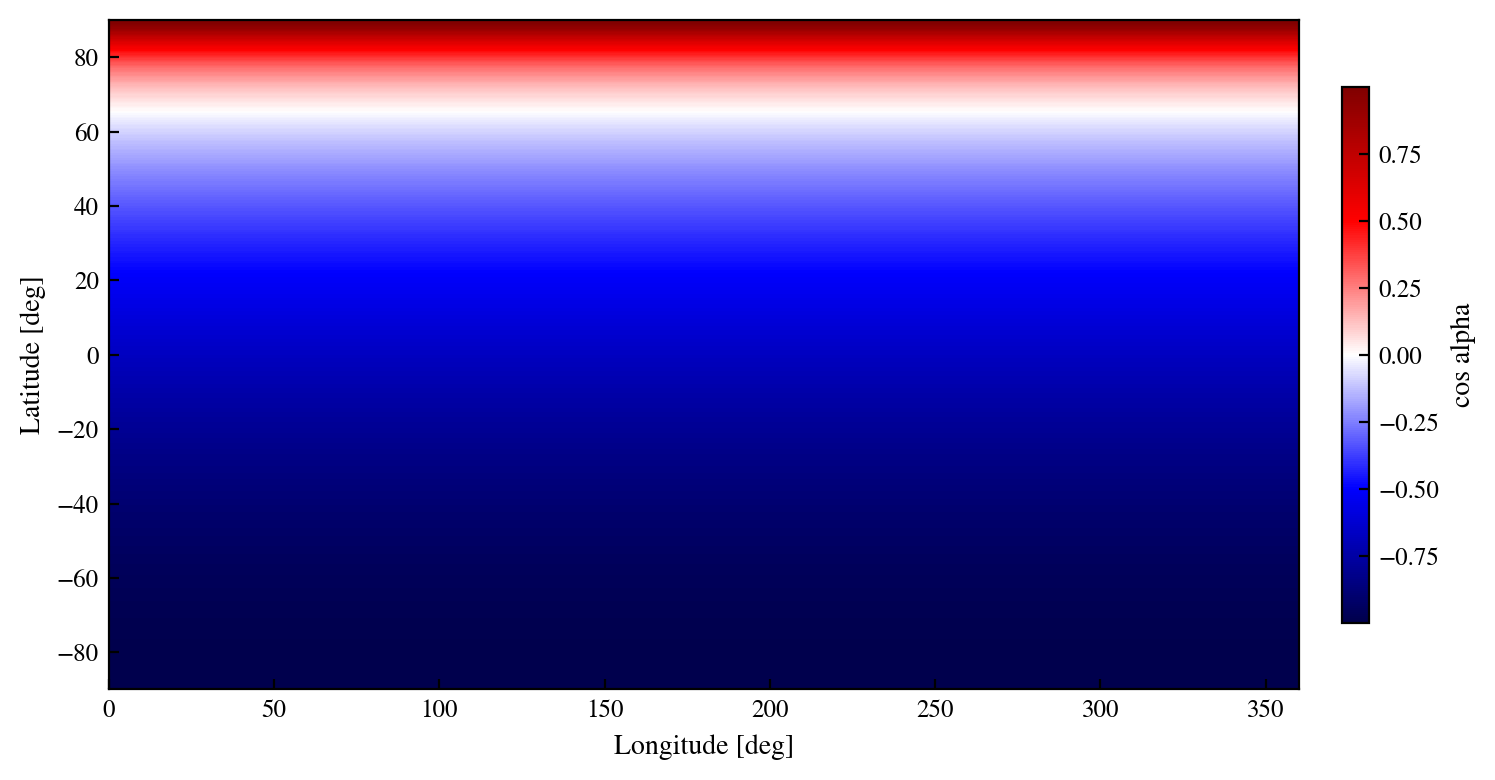

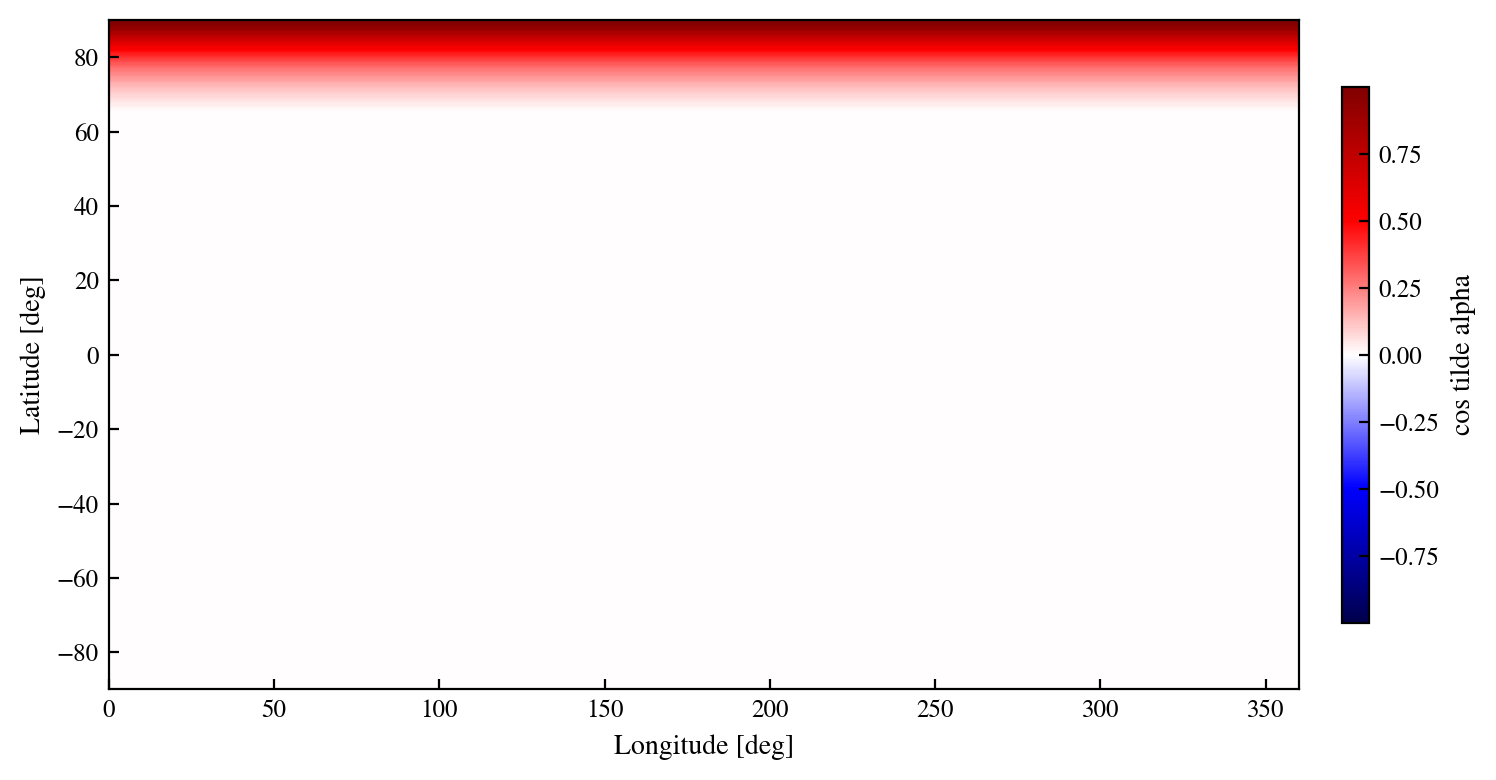

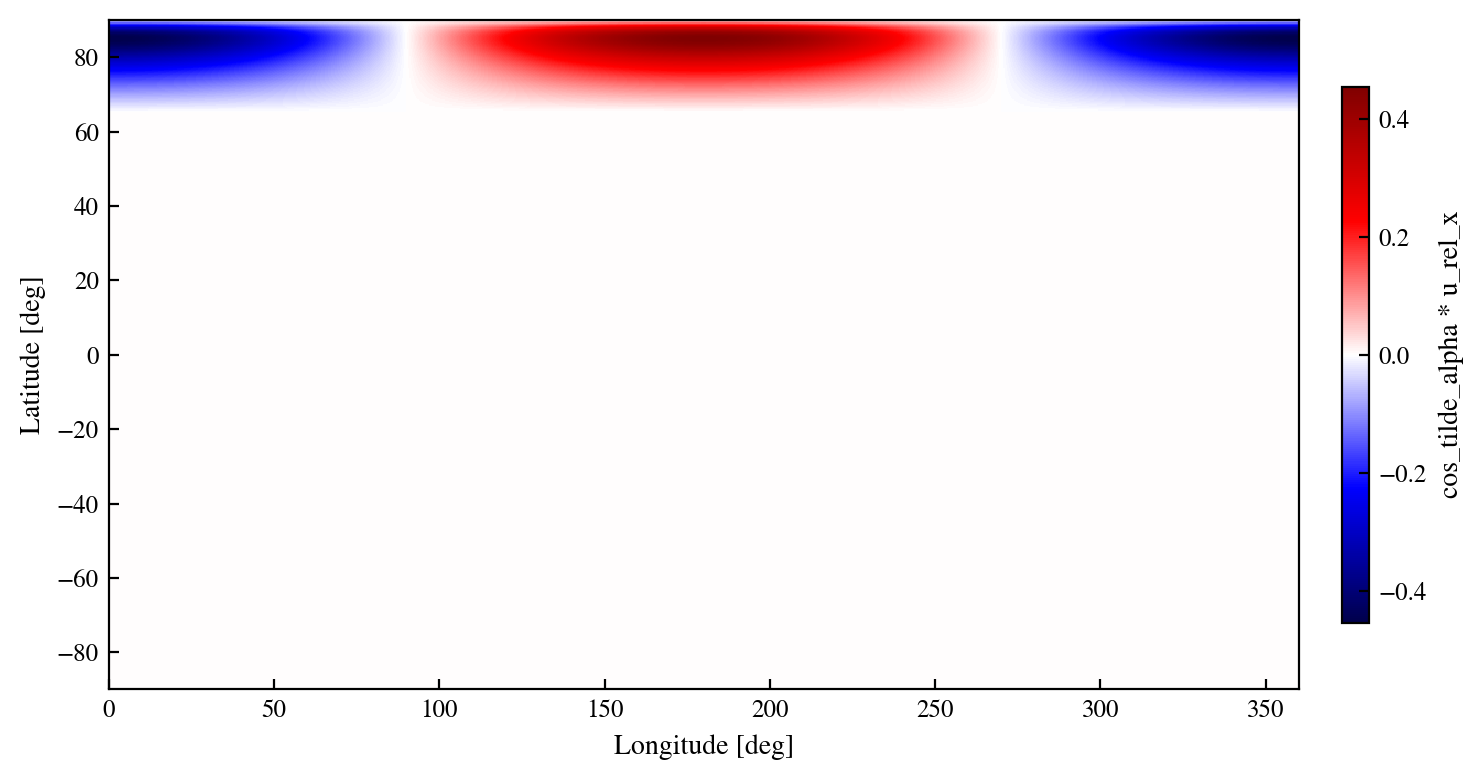

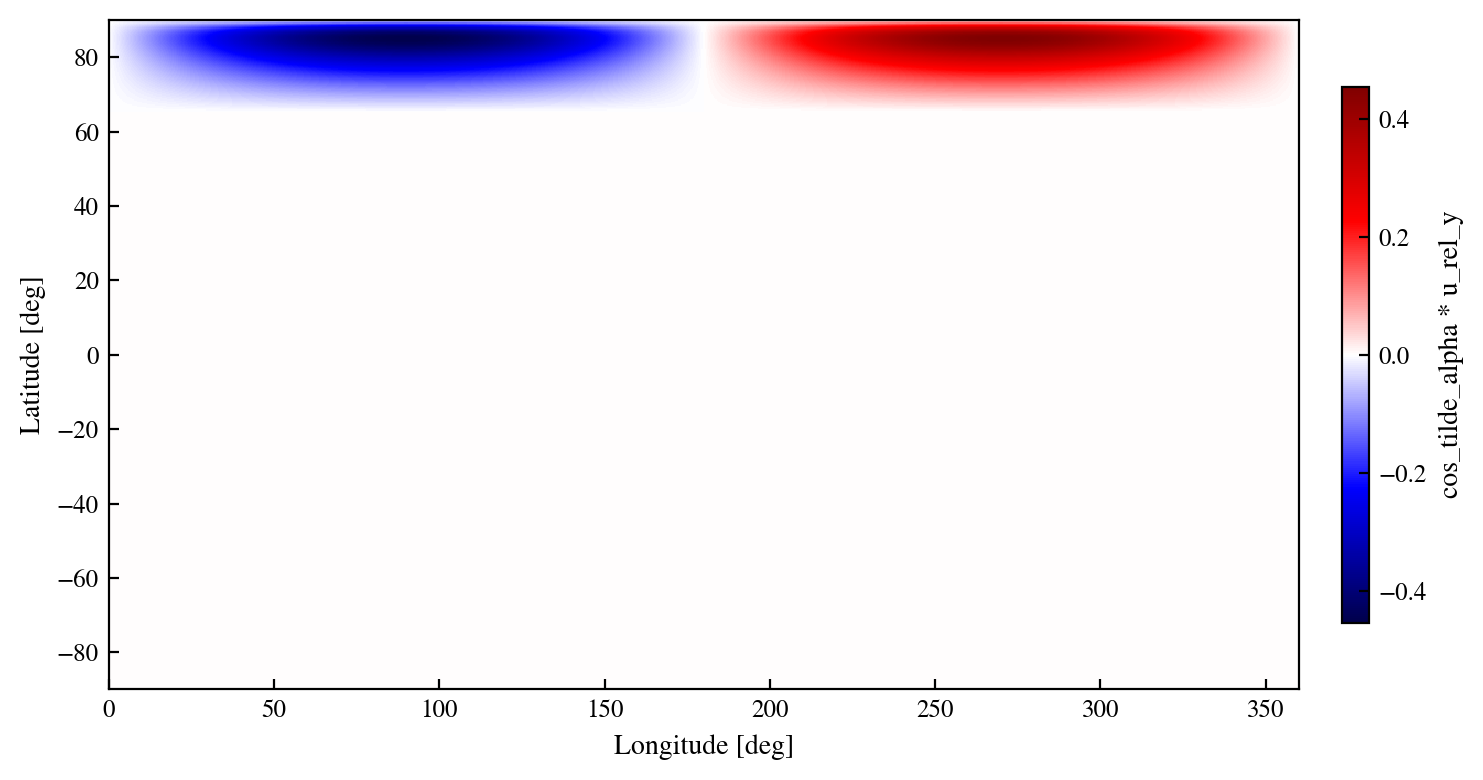

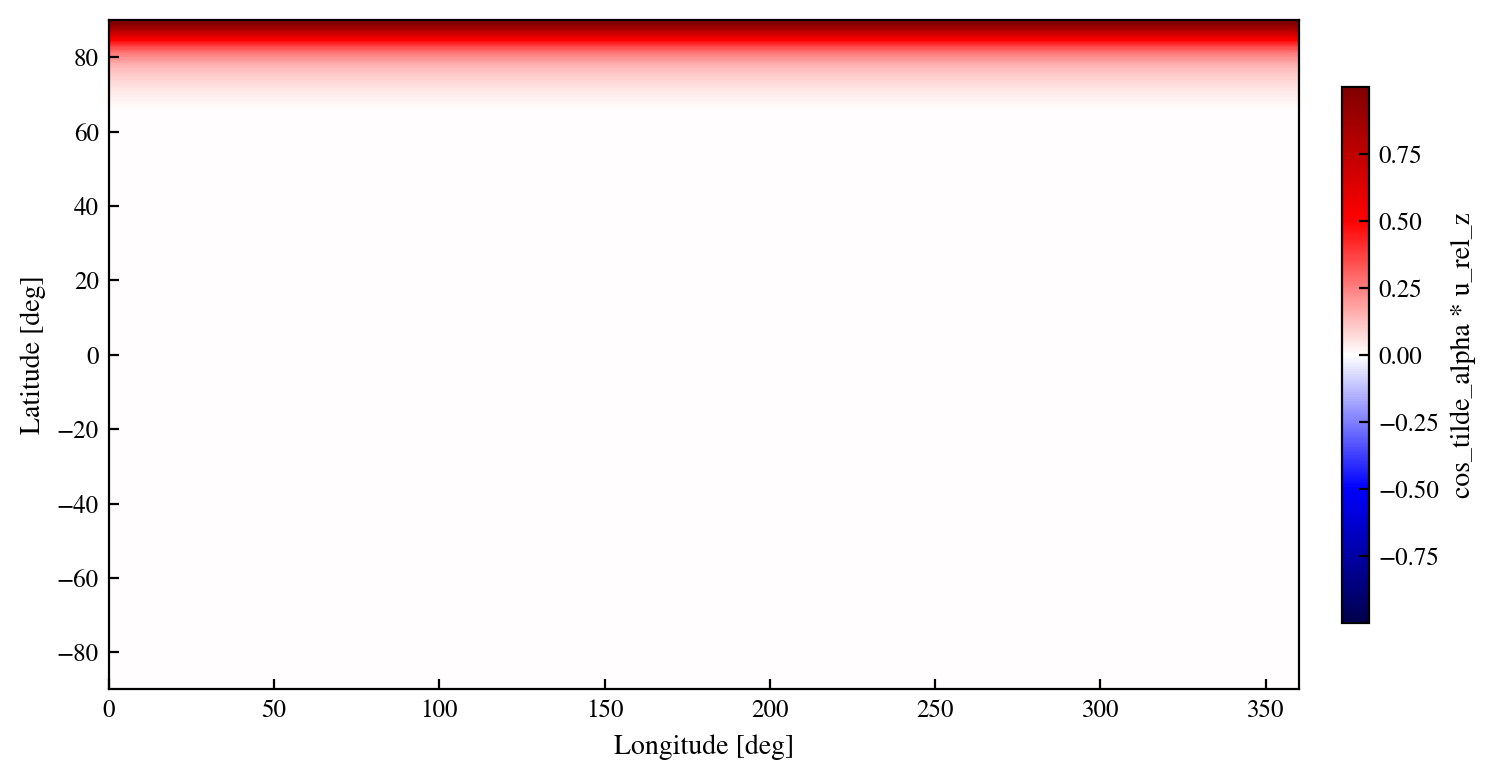

In [11]:
import numpy as np
import pyshtools as pysh

from SpaceBalls.sph_meshing import get_sphere_grid, lonlat_to_r, get_spherical_grid_cell_areas
from SpaceBalls.plotter import Plotter
import config.constants as constants

Re = constants.earth_radius()

n_lon, n_lat = 360*3, 180*3
lon_vec, lat_vec, lon_edges_vec, lat_edges_vec = get_sphere_grid(n_lon, n_lat)
grid_r_el = lonlat_to_r(lon_vec, lat_vec, 0, "spherical")

r = np.array([0,0,1.1*Re])    # position vector of satellite
r_rel = r[None,None,:]- grid_r_el
r_rel_norm = np.linalg.norm(r_rel, axis=2)
u_rel = r_rel/r_rel_norm[:,:,None]

rS_dot_r_rel = np.sum(r_rel*grid_r_el, axis=2)

cos_alpha = rS_dot_r_rel / (Re * r_rel_norm)
cos_tilde_alpha = 0.5*cos_alpha + 0.5 * np.sqrt(cos_alpha**2)

Plotter.plot_geo_data(cos_alpha, lon_edges_vec, lat_edges_vec, 'cos alpha')
Plotter.plot_geo_data(cos_tilde_alpha, lon_edges_vec, lat_edges_vec, 'cos tilde alpha')

Plotter.plot_geo_data(cos_tilde_alpha * u_rel[:,:,0], lon_edges_vec, lat_edges_vec, 'cos_tilde_alpha * u_rel_x')
Plotter.plot_geo_data(cos_tilde_alpha * u_rel[:,:,1], lon_edges_vec, lat_edges_vec, 'cos_tilde_alpha * u_rel_y')
Plotter.plot_geo_data(cos_tilde_alpha * u_rel[:,:,2], lon_edges_vec, lat_edges_vec, 'cos_tilde_alpha * u_rel_z')

#r_dot_rS = np.dot(r[None,None,:], grid_r_el)


In [12]:
h_unit = np.random.rand(3)
h_unit = h_unit / np.linalg.norm(h_unit)
r_unit = r / np.linalg.norm(r)
u_I = np.linalg.cross(h_unit, r_unit)

M_IJK_RIC = np.array([r_unit, u_I, h_unit])


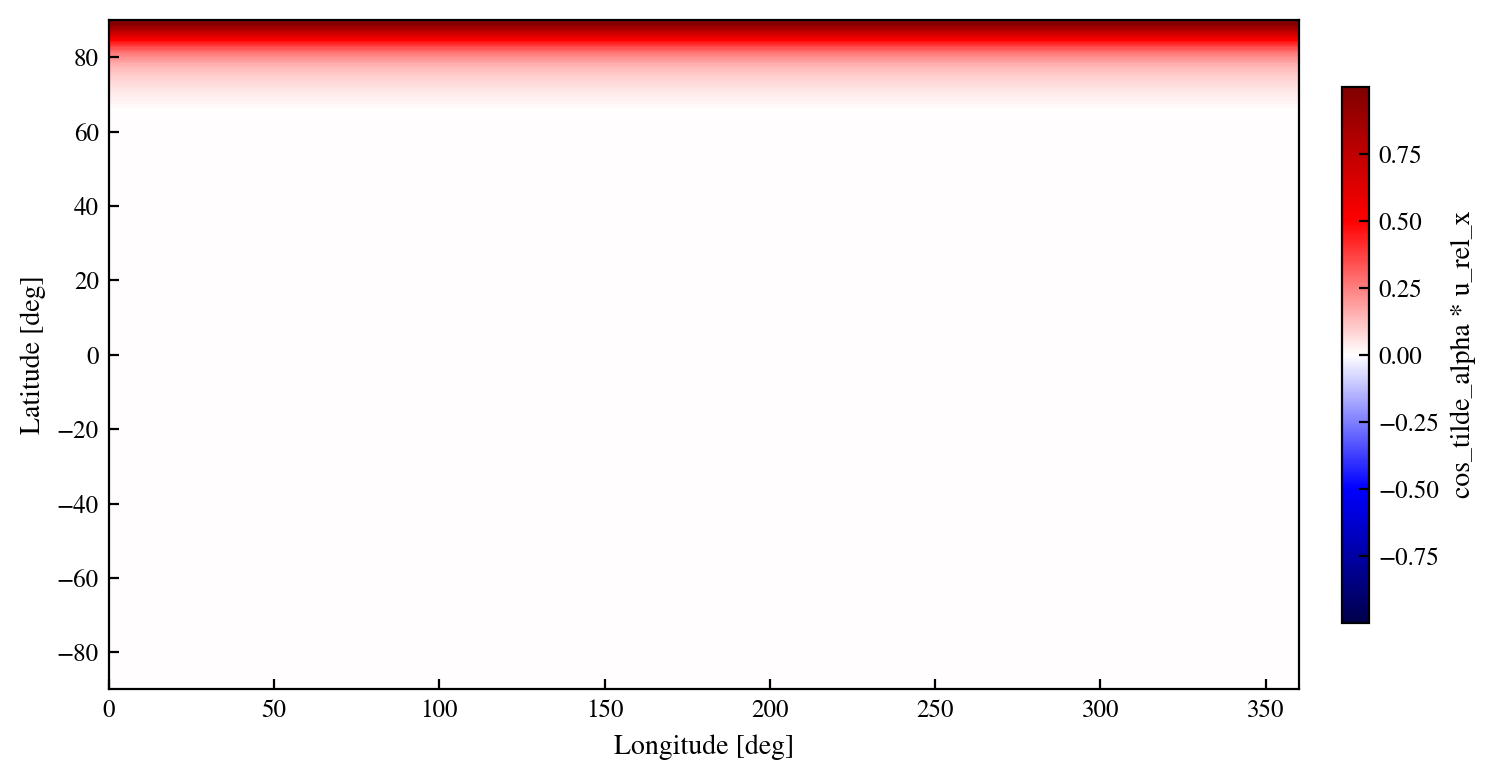

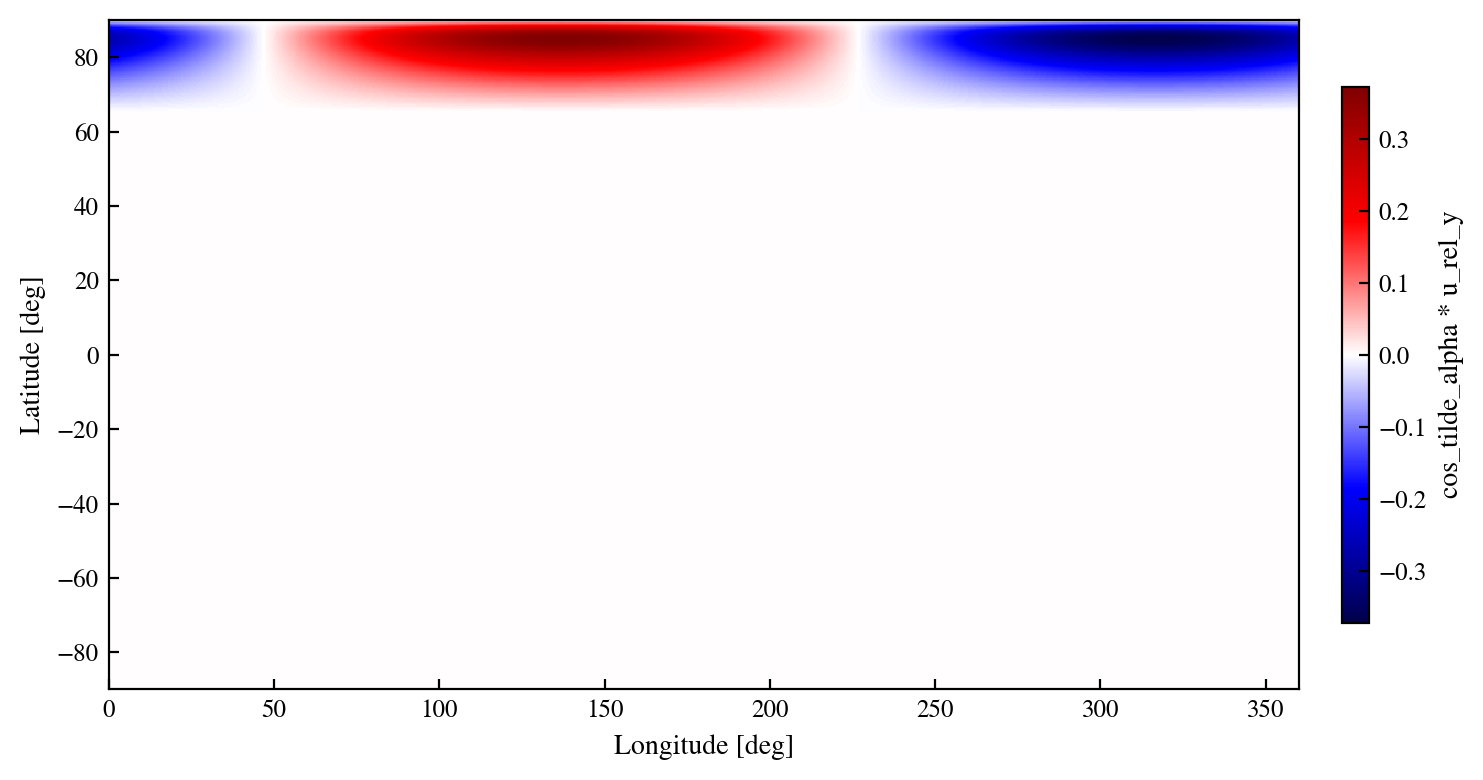

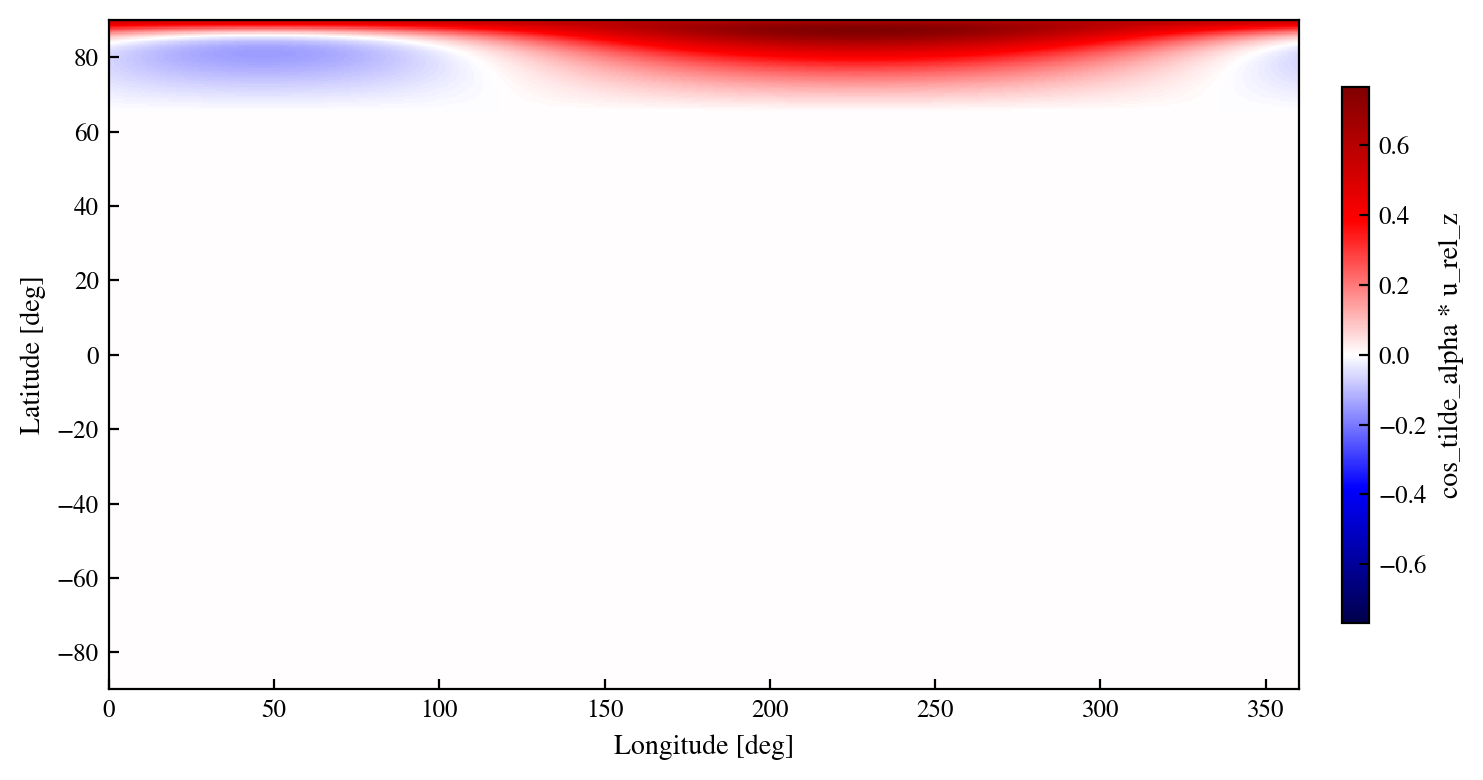

In [13]:
u_rel_RIC = u_rel @ M_IJK_RIC.T     # yes this multiplies all the vectors in the map by the matrix

#Plotter.plot_geo_data(u_rel_RIC[:,:,0], lon_edges_vec, lat_edges_vec, 'u_rel_R')
#Plotter.plot_geo_data(u_rel_RIC[:,:,1], lon_edges_vec, lat_edges_vec, 'u_rel_I')
#Plotter.plot_geo_data(u_rel_RIC[:,:,2], lon_edges_vec, lat_edges_vec, 'u_rel_C')

Fx, Fy, Fz = [cos_tilde_alpha * u_rel_RIC[:,:,i] for i in range(3)]
Plotter.plot_geo_data(Fx, lon_edges_vec, lat_edges_vec, 'cos_tilde_alpha * u_rel_x')
Plotter.plot_geo_data(Fy, lon_edges_vec, lat_edges_vec, 'cos_tilde_alpha * u_rel_y')
Plotter.plot_geo_data(Fz, lon_edges_vec, lat_edges_vec, 'cos_tilde_alpha * u_rel_z')


 Warning --- SHExpandLSQ
 Consider changing parameter value of OPT to          128  and recompiling the SHTOOLS archive.


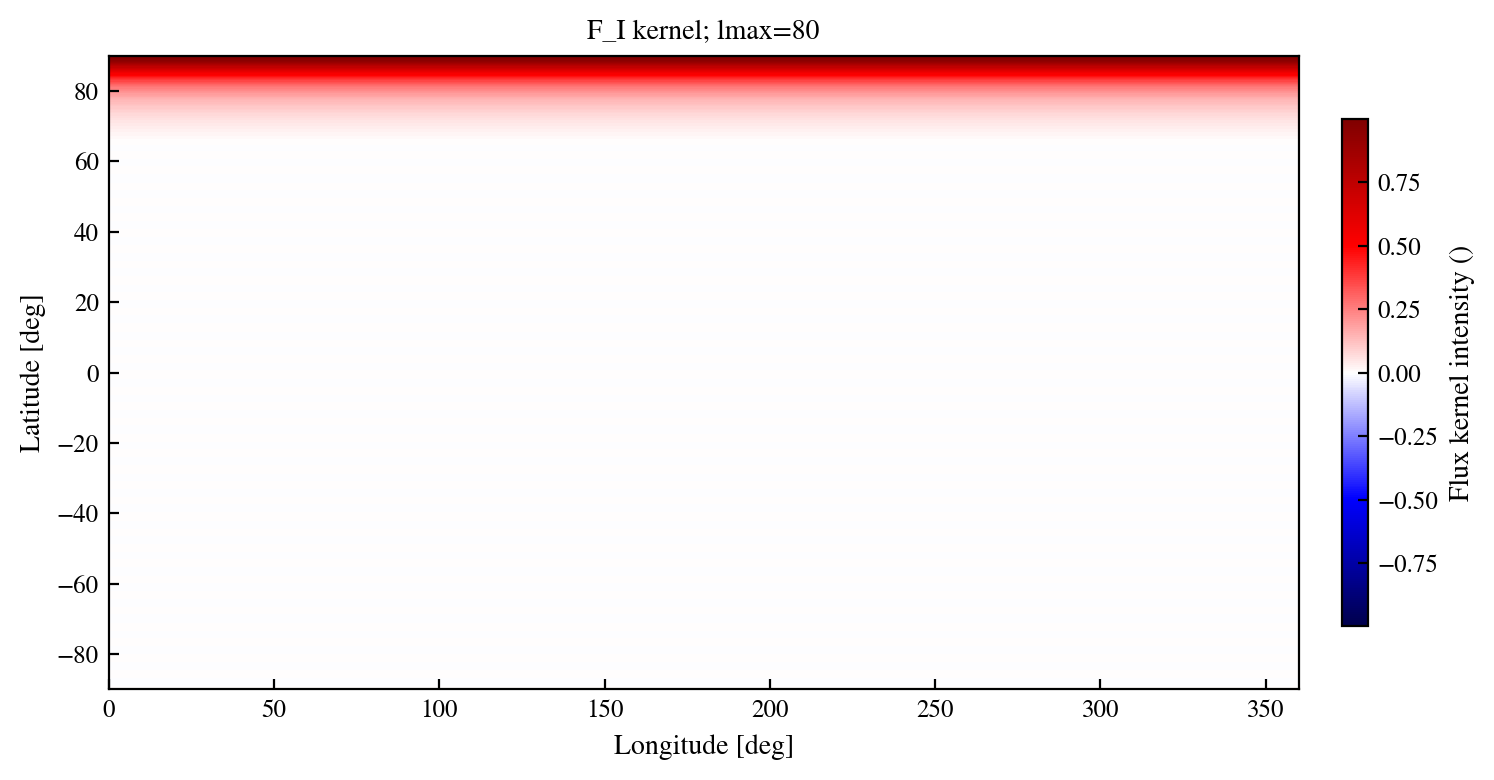

In [14]:

from SpaceBalls.sph_meshing import get_sphere_grid, get_reshaped_grid
from SpaceBalls.radiation_settings import get_a_and_e_sh_maps, convert_sh_maps_monte_to_numpy

full_lon_vec, full_lat_vec, _ = get_reshaped_grid(lon_vec, lat_vec)
#sh_grid = pysh.SHGrid.from_array(Fx)

lmax = 80

kernel_sh_coeffs = pysh.SHCoeffs.from_least_squares(np.reshape(Fx, n_lon*n_lat), longitude=full_lon_vec, 
                                             latitude=full_lat_vec, lmax=lmax, normalization='4pi')

expanded_sh = kernel_sh_coeffs.expand(lon=full_lon_vec, lat=full_lat_vec)
expanded_sh = np.reshape(expanded_sh, (n_lat, n_lon))
#true_avg = np.sum(expanded_sh * areas) / np.sum(areas)
#print(f"True avg: {true_avg}")

Plotter.plot_geo_data(expanded_sh, lon_edges_vec, lat_edges_vec, 
                    title=f"F_I kernel; lmax={lmax}", data_label='Flux kernel intensity ()')


In [ ]:
from SpaceBalls.radiation_settings import get_ae_sh_maps_numpy_new

a_CS, e_CS = get_ae_sh_maps_numpy_new(mode='historic_SYN1deg', date='2018-01-01')
e_sh_coeffs = pysh.SHCoeffs.from_array(e_CS, normalization='unnorm')
expanded_e = e_sh_coeffs.expand(lat=full_lat_vec, lon=full_lon_vec)
expanded_e = np.reshape(expanded_e, (n_lat, n_lon))

e_sh_coeffs = e_sh_coeffs.convert(normalization='4pi')

Plotter.plot_geo_data(expanded_e, lon_edges_vec, lat_edges_vec)

area_elements = get_spherical_grid_cell_areas(lat_edges_vec, lon_edges_vec)
integral_surf = np.sum(area_elements * expanded_e * Fx) / np.sum(area_elements)

if np.prod(np.shape(e_sh_coeffs.coeffs))==np.prod(np.shape(kernel_sh_coeffs.coeffs)):
    integral_coeffs = np.sum(e_sh_coeffs.coeffs * kernel_sh_coeffs.coeffs)
elif np.prod(np.shape(e_sh_coeffs.coeffs))<np.prod(np.shape(kernel_sh_coeffs.coeffs)):
    dim_diff = np.array(np.shape(kernel_sh_coeffs.coeffs)) - np.array(np.shape(e_sh_coeffs.coeffs))
    e_sh_coeffs_extended = np.pad(e_sh_coeffs.coeffs, ((0, 0),(0,dim_diff[1]),(0,dim_diff[2])), 'constant', constant_values=(0, 0))
    integral_coeffs = np.sum(e_sh_coeffs_extended * kernel_sh_coeffs.coeffs)

print(integral_surf)
print(integral_coeffs)

